Game addiction sroce predictor

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


import warnings
warnings.filterwarnings('ignore')

Loading data

In [58]:
data=pd.read_csv("Gaming_Academic_Performance.csv")
df=pd.DataFrame(data)
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


Cleaning data

In [59]:
df=df.dropna()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


student_id          0
age                 0
gender              0
gaming_hours        0
study_hours         0
sleep_hours         0
attendance          0
gaming_genre        0
social_activity     0
device_usage        0
reaction_time_ms    0
addiction_score     0
stress_level        0
grades              0
dtype: int64

Label encoding

In [60]:
encoder=LabelEncoder()
df['gender_encoded']=encoder.fit_transform(df['gender'])
df.head()

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,gender_encoded
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555,1
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000,1
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000,0
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000,0
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000,0


One-hot encoding

In [61]:
# df['stress_level']=pd.get_dummies(df,columns="stress_level")

Spliting X and y

In [62]:
X=df[['gaming_hours','sleep_hours','social_activity','device_usage','reaction_time_ms']]
y=df['addiction_score']

Train test split

In [63]:
XTrain,XTest,yTrain,yTest=train_test_split(X,y,random_state=42,test_size=0.3)

Random forest classifier

In [ ]:
model=RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(XTrain,yTrain)
prediction=model.predict(XTest)

Evaluation of model

In [65]:
print(f"MAE: {mean_absolute_error(yTest,prediction)}")
print(f"MSE: {mean_squared_error(yTest,prediction)}")
print(f"RMSE: {np.sqrt(mean_squared_error(yTest,prediction))}")
print(f"R2: {r2_score(yTest,prediction)}")

MAE: 1.6166204166666664
MSE: 4.1169634283833325
RMSE: 2.0290301694118136
R2: 0.8349466773394086


Model vs actual prediction

   Actual  Predicted
0    9.17     7.2552
1   -0.61     2.3764
2   13.59    10.6502
3   14.06    16.0313
4    7.66     6.0273


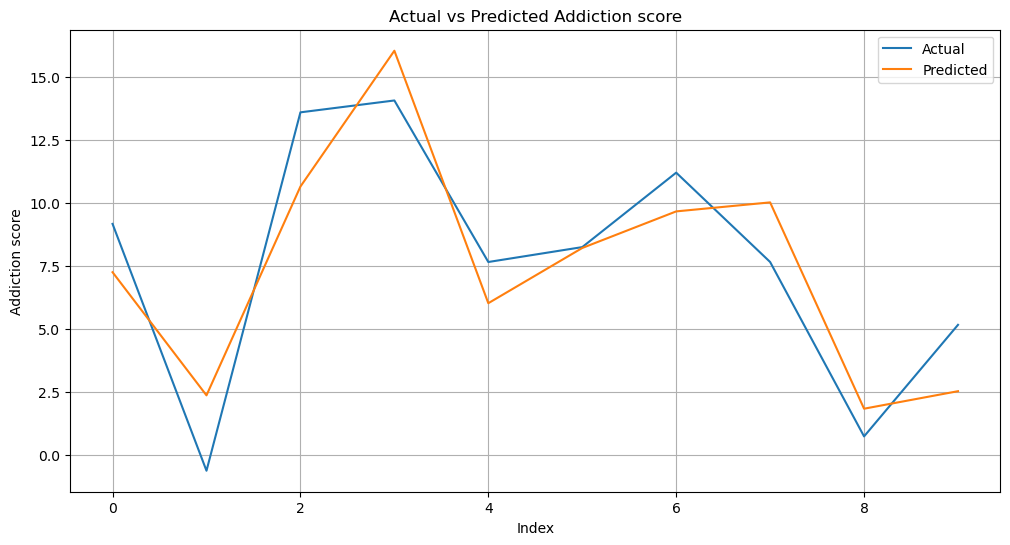

In [66]:
result=pd.DataFrame({
    'Actual': yTest.values,
    'Predicted':prediction
})

print(result.head())

result=result.head(10)
plt.figure(figsize=(12,6))
sns.lineplot(data=result,x=result.index,y='Actual',label="Actual")
sns.lineplot(data=result,x=result.index,y="Predicted",label="Predicted")
plt.title("Actual vs Predicted Addiction score")
plt.xlabel("Index")
plt.ylabel("Addiction score")
plt.legend()
plt.grid(True)
plt.show()

Inputs

In [67]:
try:
    gamingHours=float(input("Enter gaming hours: "))
    sleepHours=float(input("Enter sleep hours: "))
    socialActivity=float(input("Enter social activity: "))
    deviceUsage=float(input("Enter device usage: "))
    reactionTime=float(input("Enter reaction time(ms): "))

    userInput = pd.DataFrame([[gamingHours, sleepHours, socialActivity,
                               deviceUsage, reactionTime]],
                             columns=X.columns)

    result=model.predict(userInput)
    print(f"Predicted Addiction Score: {result[0]:.2f}")
except:
    print("An error occuried")

Predicted Addiction Score: 15.57
